# Maternal Digital Twin — Thyroid Dysfunction Prediction

## 1. Objective

This notebook implements the **Thyroid Dysfunction prediction module** (Module 3 of 4) of the
*Maternal Digital Twin* capstone project. The goal is to predict, from **first-trimester baseline**
information, whether a pregnant woman who does **not** have thyroid dysfunction at baseline will go on
to develop it **later in pregnancy** (second or third trimester).

This is a **student academic prototype for healthcare decision support**. It is **not a diagnostic tool**
and must not be used to make real clinical decisions. All findings are specific to this dataset.

## 2. Dataset

- **Source study:** Zhou Y, Wang Y, Yu T, Li Y, Mi M, Su J, Ge J. (2025). *Subclinical hypothyroidism
  during pregnancy and the impact of levothyroxine therapy on pregnancy outcomes in women.*
  PeerJ 13:e19343. https://doi.org/10.7717/peerj.19343
- **File:** `origin_data.xlsx` (single sheet, verified below)
- **Cohort (per the source paper):** 938 pregnant women seen at The Fourth Hospital of Shijiazhuang
  (Jan 2019 – Dec 2020), each with thyroid function tests recorded at **three pregnancy occasions**
  (approximately one per trimester). The published cohort comprises 266 women with subclinical
  hypothyroidism (SCH) who were treated with levothyroxine (LT4), and 672 women without SCH.
- **This is a treated cohort.** Any woman diagnosed with SCH in this study started LT4 treatment
  immediately, so thyroid values measured *after* a diagnosis reflect treatment response, not untreated
  natural history. This has direct consequences for how the prediction target is defined (Section 5).

We will **verify every structural claim about this dataset directly against the file** before using it,
rather than assuming it is correct.


## 3. Dataset Verification

We load the file, confirm its shape/columns, and independently check every "known fact" supplied about
this dataset (row count, unique IDs, duplicates, missingness patterns, special lab-value codes) before
relying on any of it.


In [2]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, brier_score_loss, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Run `pip install xgboost` and restart the kernel to enable it.")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed. Run `pip install shap` and restart the kernel to enable SHAP analysis.")

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"SHAP available: {SHAP_AVAILABLE}")


XGBoost available: True
SHAP available: True


In [3]:
DATA_PATH = "origin_data.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Could not find '{DATA_PATH}'. Place it in the project root.")

xl = pd.ExcelFile(DATA_PATH)
print("Sheet names:", xl.sheet_names)

# The source file is loaded read-only from this point on; df_raw is never modified or re-saved
df_raw = xl.parse(xl.sheet_names[0])
df = df_raw.copy()

print("Shape:", df.shape)


Sheet names: ['938 people were analyzed']
Shape: (938, 87)


In [4]:
# First rows
df.head()


,ID,Age,Last menstruation,Education level High school 1 Junior College 2 Undergraduate graduate 3,Prepregnancy weight,height,BMI,"Annual household income, 1= less than 50,000, 2= 50,000 to 100,000 = more than 100,000",parity,Family history of diabetes,...,Newborn weight,Normal weight 0 low 1 high 2,GENDER,Hypoglycemia occurs,Neonatal hyperbilirubinemia,Atrioventricular septal defect,Neonatal respiratory distress syndrome,Neonatal infection,Neonatal pneumonia,Delivery mode
0,1,30,11.1,1.0,66.0,163.0,24.840980,1,2,0,...,3430,0,1.0,0,0,0,0,0,0,Cesarean section
1,2,27,10.3,2.0,52.0,163.0,19.571681,1,1,0,...,3040,0,1.0,0,0,0,0,0,0,eutocia
2,3,30,NaN,1.0,40.0,160.0,15.625000,2,2,1,...,3890,0,1.0,0,0,0,0,0,0,Cesarean section
3,4,24,11.12,3.0,61.0,170.0,21.107266,3,1,0,...,3390,0,2.0,0,0,0,0,1,0,Cesarean section
4,5,25,10.18,3.0,46.0,158.0,18.426534,3,1,0,...,2750,0,1.0,0,1,0,0,0,0,Cesarean section


In [5]:
# Column names (all 87)
for i, c in enumerate(df.columns):
    print(i, repr(c))


0 'ID'
1 'Age'
2 'Last menstruation'
3 'Education level High school 1 Junior College 2 Undergraduate graduate 3'
4 'Prepregnancy weight'
5 'height'
6 'BMI'
7 'Annual household income, 1= less than 50,000, 2= 50,000 to 100,000 = more than 100,000'
8 'parity'
9 'Family history of diabetes'
10 'Smoking or secondhand smoke exposure for more than 15 minutes per week'
11 'Alcohol consumption'
12 'Folic acid supplementation'
13 'VD supplementation is not 0 before pregnancy 1 early pregnancy 2'
14 1
15 'TSH'
16 'FT3'
17 'FT4'
18 'TPO'
19 'iron'
20 'zinc'
21 'magnesium'
22 'phosphorus'
23 'copper'
24 'calcium'
25 'Homocysteine'
26 'SF'
27 'VB12'
28 'Folic acid'
29 'TG'
30 'TC'
31 'HDL'
32 'LDL'
33 'TSH2'
34 'FT32'
35 'FT42'
36 'TPO2'
37 'iron.1'
38 'zinc.1'
39 'calcium.1'
40 'FPG'
41 'PG1H'
42 'PG2H'
43 'SF.1'
44 'VB12.1'
45 'Folic acid.1'
46 'TSH3'
47 'FT33'
48 'FT43'
49 'TPO3'
50 'iron.2'
51 'zinc.2'
52 'magnesium.1'
53 'phosphorus.1'
54 'copper.1'
55 'calcium.2'
56 'TG.1'
57 'TC.1'
58 'HDL.1

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 87 columns):
 #   Column                                                                                  Non-Null Count  Dtype  
---  ------                                                                                  --------------  -----  
 0   ID                                                                                      938 non-null    int64  
 1   Age                                                                                     938 non-null    int64  
 2   Last menstruation                                                                       556 non-null    object 
 3   Education level High school 1 Junior College 2 Undergraduate graduate 3                 562 non-null    float64
 4   Prepregnancy weight                                                                     556 non-null    float64
 5   height                                                                            

In [7]:
# Verify: unique patient IDs, no duplicate IDs, no fully duplicated rows
print("Unique IDs:", df['ID'].nunique(), "/", len(df))
print("Duplicate ID rows:", df['ID'].duplicated().sum())
print("Fully duplicated rows:", df.duplicated().sum())


Unique IDs: 938 / 938
Duplicate ID rows: 0
Fully duplicated rows: 0


In [8]:
# Full missingness / dtype / cardinality table, with a manually-assigned "role" for every column.
# Roles are assigned AFTER inspecting each column's meaning, not from the name alone.
column_roles = {
    'ID': 'identifier',
    'Age': 'predictor',
    'Last menstruation': 'unusable',  # mixed date/float formats, 40.7% missing, administrative field
    'Education level High school 1 Junior College 2 Undergraduate graduate 3': 'uncertain',  # 40% missing, tied to an admin data block
    'Prepregnancy weight': 'unusable',  # 40.7% missing; redundant with complete BMI
    'height': 'unusable',              # 40.7% missing; redundant with complete BMI
    'BMI': 'predictor',
    'Annual household income, 1= less than 50,000, 2= 50,000 to 100,000 = more than 100,000': 'predictor',
    'parity': 'predictor',
    'Family history of diabetes': 'predictor',
    'Smoking or secondhand smoke exposure for more than 15 minutes per week': 'predictor',
    'Alcohol consumption': 'predictor',
    'Folic acid supplementation': 'predictor',
    'VD supplementation is not 0 before pregnancy 1 early pregnancy 2': 'predictor',
    1: 'uncertain',  # unlabeled column, ambiguous meaning -- see EDA
    'TSH': 'predictor',           # baseline (occasion 1)
    'FT3': 'predictor',           # baseline (occasion 1)
    'FT4': 'predictor',           # baseline (occasion 1) -- also target component
    'TPO': 'predictor',           # baseline (occasion 1)
    'iron': 'unusable', 'zinc': 'unusable', 'magnesium': 'unusable', 'phosphorus': 'unusable',
    'copper': 'unusable', 'calcium': 'unusable', 'Homocysteine': 'unusable',
    'SF': 'unusable', 'VB12': 'unusable', 'Folic acid': 'unusable',  # 100% empty
    'TG': 'unusable', 'TC': 'unusable', 'HDL': 'unusable', 'LDL': 'unusable',
    'TSH2': 'target component', 'FT32': 'leakage', 'FT42': 'target component', 'TPO2': 'leakage',
    'iron.1': 'leakage', 'zinc.1': 'leakage', 'calcium.1': 'leakage',
    'FPG': 'leakage', 'PG1H': 'leakage', 'PG2H': 'leakage',
    'SF.1': 'leakage', 'VB12.1': 'leakage', 'Folic acid.1': 'leakage',
    'TSH3': 'target component', 'FT33': 'leakage', 'FT43': 'target component', 'TPO3': 'leakage',
    'iron.2': 'leakage', 'zinc.2': 'leakage', 'magnesium.1': 'leakage', 'phosphorus.1': 'leakage',
    'copper.1': 'leakage', 'calcium.2': 'leakage', 'TG.1': 'leakage', 'TC.1': 'leakage',
    'HDL.1': 'leakage', 'LDL.1': 'leakage', 'Homocysteine.1': 'leakage',
    'SF.2': 'leakage', 'VB12.2': 'leakage', 'Folic acid.2': 'leakage', 'CRP(0-10)': 'leakage',
    'Gestational age': 'leakage', 'Gestational age+': 'leakage', 'Gestation days': 'leakage',
    'Delivery methods: 1 straight, 2 sections, 3 assists': 'leakage',
    'Uterine myoma': 'leakage', 'Pregnutose termination': 'leakage',
    'Anemia 1 mild 2 moderate to severe': 'leakage', 'Chorioamniotic inflammation': 'leakage',
    'Premature rupture of membranes': 'leakage', 'Premature birth': 'leakage',
    'Hypertensive disease': 'leakage', 'Postpartum hemorrhage': 'leakage',
    'Newborn weight': 'leakage', 'Normal weight 0 low 1 high 2': 'leakage', 'GENDER': 'leakage',
    'Hypoglycemia occurs': 'leakage', 'Neonatal hyperbilirubinemia': 'leakage',
    'Atrioventricular septal defect': 'leakage', 'Neonatal respiratory distress syndrome': 'leakage',
    'Neonatal infection': 'leakage', 'Neonatal pneumonia': 'leakage', 'Delivery mode': 'leakage',
}

assert set(column_roles.keys()) == set(df.columns), "Every column must have an assigned role"

role_table = pd.DataFrame({
    'column': [str(c) for c in df.columns],
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isnull().sum().values,
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2).values,
    'unique_count': df.nunique(dropna=True).values,
    'role': [column_roles[c] for c in df.columns],
})
role_table


,column,dtype,missing_count,missing_pct,unique_count,role
0,ID,int64,0,0.00,938,identifier
1,Age,int64,0,0.00,22,predictor
2,Last menstruation,object,382,40.72,397,unusable
3,Education level High school 1 Junior College 2...,float64,376,40.09,3,uncertain
4,Prepregnancy weight,float64,382,40.72,63,unusable
...,...,...,...,...,...,...
82,Atrioventricular septal defect,int64,0,0.00,2,leakage
83,Neonatal respiratory distress syndrome,int64,0,0.00,2,leakage
84,Neonatal infection,int64,0,0.00,2,leakage
85,Neonatal pneumonia,int64,0,0.00,2,leakage


**Verification notes:**

- The row count (938), unique-ID count (938, no duplicates), and zero fully-duplicated rows are all
  confirmed directly against the file.
- `TSH`, `FT3`, `FT4` are complete (0% missing) at **all three** measurement occasions — confirmed.
- `TPO` missingness rises from 6.4% (occasion 1) to 80.6% (occasion 2) and 50.2% (occasion 3) — the
  general pattern of "substantial missingness at later occasions" is confirmed, though the exact
  occasion-2/occasion-3 ordering differs from a simple monotonic increase.
- `SF`, `VB12`, `Folic acid` (baseline, unsuffixed) are **completely empty** (100% missing) — confirmed;
  these plus their `.1`/`.2` (occasion 2/3) counterparts are excluded.
- Micronutrient panels (`iron`, `zinc`, `magnesium`, `phosphorus`, `copper`, `calcium`,
  `Homocysteine`) at baseline have 80–99.8% missingness — confirmed as extremely high-missingness
  predictors; these are excluded rather than imputed (see Section 7).
- Column index 14 (header literally `1`) is **not documented anywhere** in the source paper or column
  names. It takes only the value 1.0 or NaN, and its missingness pattern is **identical** to
  `Education level`, `Gestational age`, `Gestational age+`, `Gestation days`, and `Delivery mode`
  (all missing for the exact same 376 women). We could not determine its clinical meaning, so it is
  marked **uncertain** and excluded from modeling rather than guessed at.
- `Last menstruation` is stored in **mixed formats** (some rows as `month.day` floats like `11.1`,
  others as full datetime strings like `2018-11-25`) and is 40.7% missing — excluded as unreliable/unusable.
- `Prepregnancy weight` and `height` are 40.7% missing, while the derived `BMI` is 0% missing — we keep
  the complete, already-derived `BMI` and drop the two high-missingness raw components rather than
  imputing them.


## 4. Exploratory Data Analysis

Focused EDA on the variables that matter for this module: the thyroid measurements across all three
occasions, demographics, missingness structure, outliers, correlations, and leakage — without repeating
plots unnecessarily.


### 4A. Thyroid variables across the three measurement occasions

`TSH`/`FT3`/`FT4` are complete at every occasion, so we can directly compare their distributions across
pregnancy.


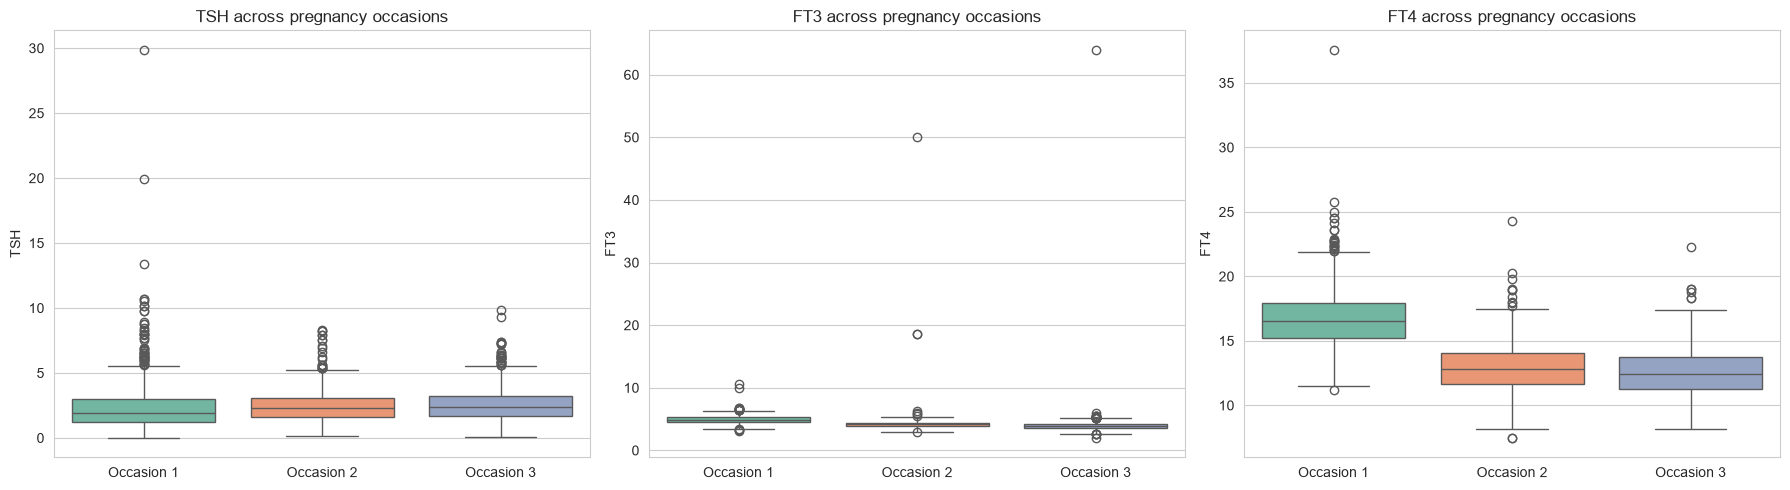

--- TSH ---
          mean       std    min   50%    max
TSH   2.408751  2.000904  0.005  1.94  29.87
TSH2  2.450329  1.171220  0.150  2.34   8.31
TSH3  2.563175  1.320219  0.067  2.39   9.88

--- FT3 ---
          mean       std   min   50%    max
FT3   4.889467  0.606119  3.08  4.87  10.56
FT32  4.231023  1.706753  2.91  4.15  50.00
FT33  3.965181  2.027807  2.00  3.88  63.97

--- FT4 ---
           mean       std    min     50%    max
FT4   16.738689  2.319077  11.18  16.555  37.56
FT42  12.921247  1.822786   7.48  12.850  24.29
FT43  12.537058  1.826225   8.13  12.410  22.25



In [9]:
thyroid_occasions = {
    'TSH':  ['TSH', 'TSH2', 'TSH3'],
    'FT3':  ['FT3', 'FT32', 'FT33'],
    'FT4':  ['FT4', 'FT42', 'FT43'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (marker, cols) in zip(axes, thyroid_occasions.items()):
    plot_df = df[cols].copy()
    plot_df.columns = ['Occasion 1', 'Occasion 2', 'Occasion 3']
    sns.boxplot(data=plot_df, ax=ax, palette='Set2')
    ax.set_title(f'{marker} across pregnancy occasions')
    ax.set_ylabel(marker)

plt.tight_layout()
plt.show()

for marker, cols in thyroid_occasions.items():
    print(f"--- {marker} ---")
    print(df[cols].describe().T[['mean', 'std', 'min', '50%', 'max']])
    print()


`TSH` is right-skewed at every occasion (mean > median, long right tail up to ~30 mIU/L), consistent
with the dataset description. `FT4` trends slightly downward across occasions (a well-documented normal
physiological pattern in pregnancy). `FT3` and `FT4` both show a handful of extreme high values (visible
as outlier points above the boxes), especially at occasion 2/3.


In [10]:
# TPO across occasions -- note occasion-1 TPO is stored as text (object dtype) because of one
# censored value ("> 600"); we only inspect missingness/shape here, cleaning happens in Section 7.
tpo_missing = pd.Series({
    'TPO (occasion 1)': df['TPO'].isnull().sum(),
    'TPO2 (occasion 2)': df['TPO2'].isnull().sum(),
    'TPO3 (occasion 3)': df['TPO3'].isnull().sum(),
})
print("TPO missing counts:")
print(tpo_missing)
print()
print("TPO missing %:")
print((tpo_missing / len(df) * 100).round(1))


TPO missing counts:
TPO (occasion 1)      60
TPO2 (occasion 2)    756
TPO3 (occasion 3)    471
dtype: int64

TPO missing %:
TPO (occasion 1)      6.4
TPO2 (occasion 2)    80.6
TPO3 (occasion 3)    50.2
dtype: float64


### 4B. Demographics

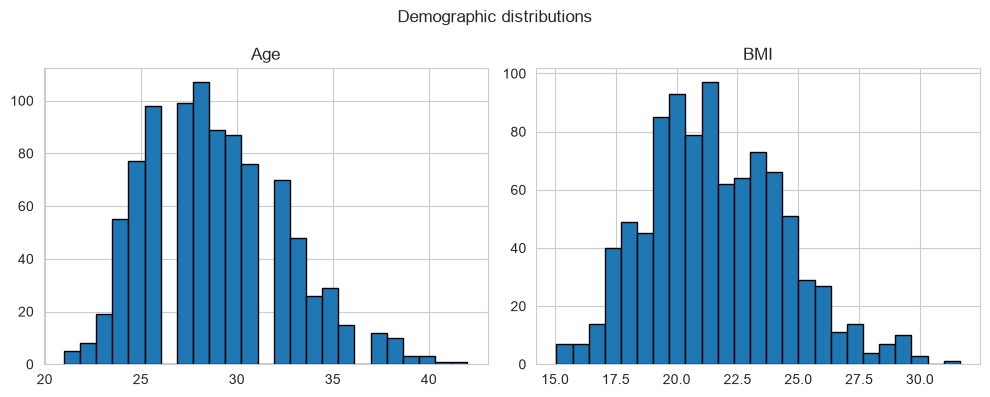

              Age         BMI
count  938.000000  938.000000
mean    28.927505   21.648994
std      3.601712    2.815935
min     21.000000   15.055139
25%     26.000000   19.571681
50%     29.000000   21.450000
75%     31.000000   23.549927
max     42.000000   31.640000


In [11]:
demo_numeric = ['Age', 'BMI']
df[demo_numeric].hist(figsize=(10, 4), bins=25, edgecolor='black')
plt.suptitle('Demographic distributions')
plt.tight_layout()
plt.show()

print(df[demo_numeric].describe())


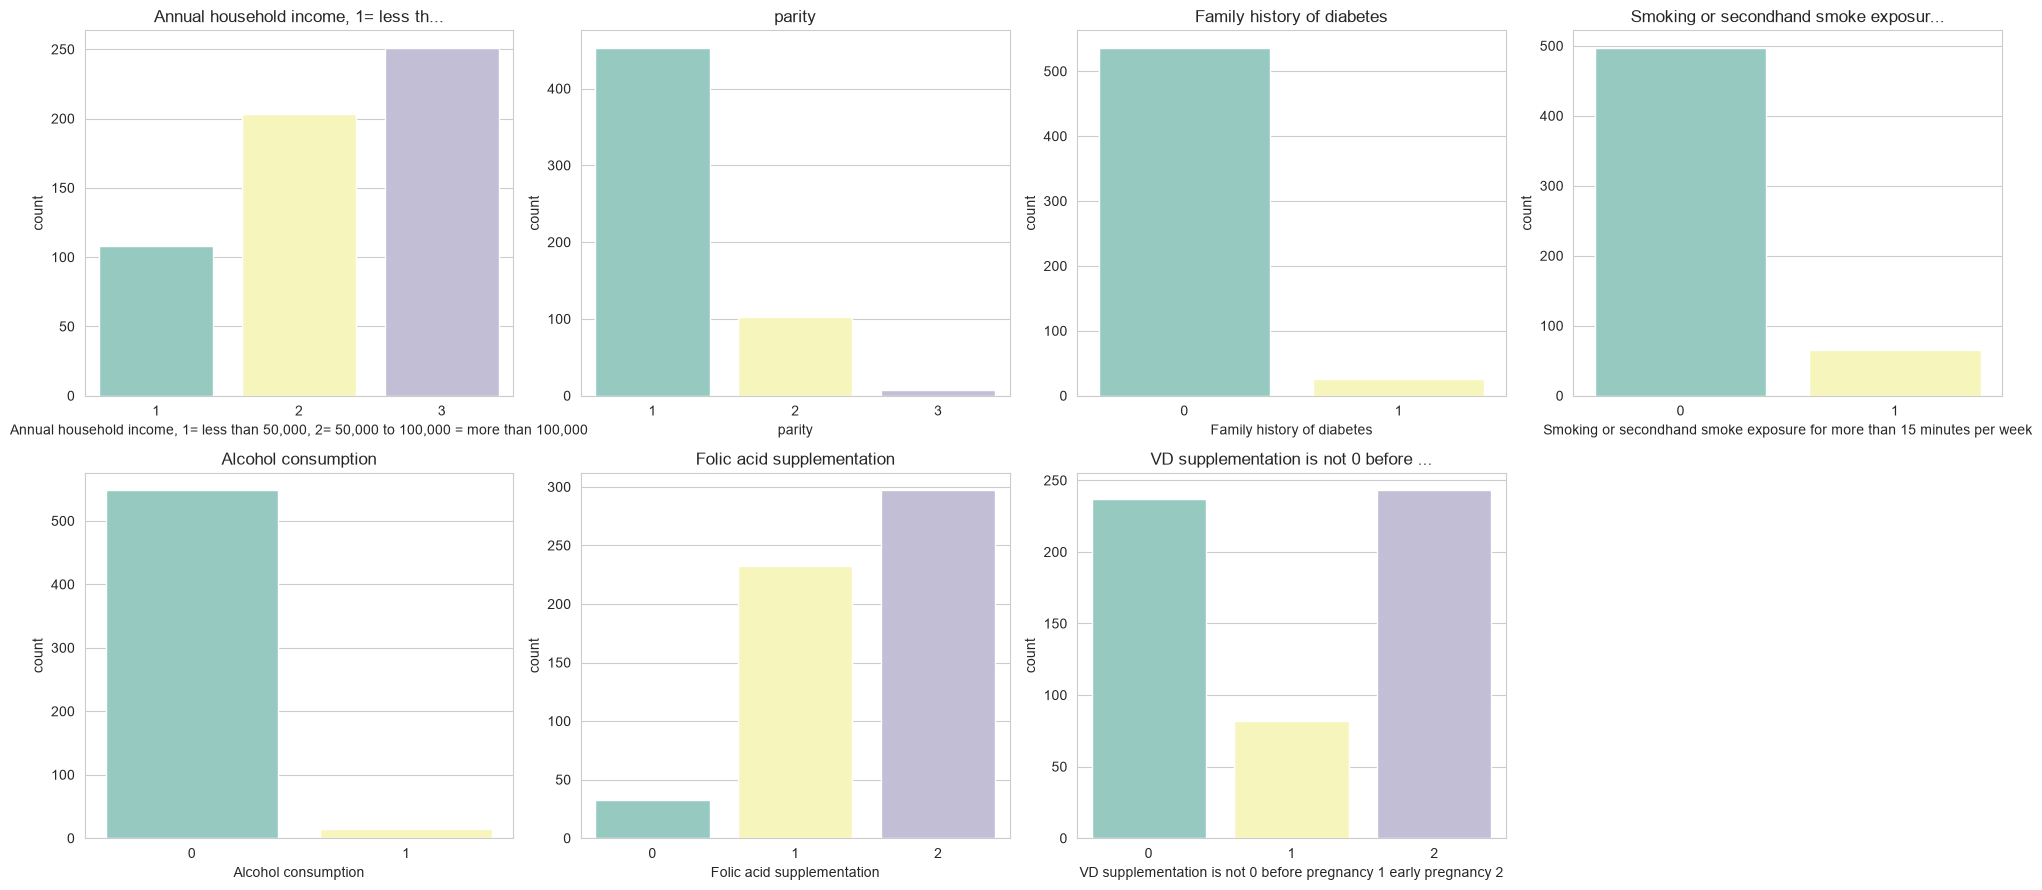

In [12]:
demo_categorical = [
    'Annual household income, 1= less than 50,000, 2= 50,000 to 100,000 = more than 100,000',
    'parity', 'Family history of diabetes',
    'Smoking or secondhand smoke exposure for more than 15 minutes per week',
    'Alcohol consumption', 'Folic acid supplementation',
    'VD supplementation is not 0 before pregnancy 1 early pregnancy 2'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(demo_categorical):
    sns.countplot(x=col, data=df, hue=col, palette='Set3', legend=False, ax=axes[i])
    axes[i].set_title(col[:35] + ('...' if len(col) > 35 else ''))
    axes[i].tick_params(axis='x', rotation=0)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


### 4C. Pregnancy / clinical variables actually present

`parity` (number of previous births: 1, 2, or 3 in this dataset) is present with 0% missing and is
plotted above. Gravidity is **not available** as a separate column in this dataset ("Not available in
this dataset"). Gestational-age-at-delivery variables exist but are post-delivery leakage (Section 6),
so they are examined only for verification, not as predictors.


### 4D. Missingness patterns

In [13]:
missing_summary = (
    df.isnull().sum()[df.isnull().sum() > 0]
    .sort_values(ascending=False)
    .to_frame('missing_count')
)
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary


,missing_count,missing_pct
VB12,938,100.00
Folic acid,938,100.00
SF,938,100.00
Homocysteine,936,99.79
Homocysteine.1,936,99.79
magnesium,935,99.68
phosphorus,935,99.68
copper,935,99.68
HDL,841,89.66
TC,841,89.66


In [14]:
# Jointly-missing block check: are these columns missing for the exact same set of women?
col14 = df.columns[14]
block_cols = [col14,
              'Education level High school 1 Junior College 2 Undergraduate graduate 3',
              'Gestational age', 'Gestational age+', 'Gestation days', 'Delivery mode']
base_mask = df[block_cols[0]].isnull()
print("Column           | Same missingness pattern as column index 14?")
for c in block_cols:
    print(f"{str(c)[:40]:40s} | {(df[c].isnull() == base_mask).all()}")
print(f"\nNumber of women affected by this joint block: {base_mask.sum()} ({base_mask.mean()*100:.1f}%)")


Column           | Same missingness pattern as column index 14?
1                                        | True
Education level High school 1 Junior Col | True
Gestational age                          | True
Gestational age+                         | True
Gestation days                           | True
Delivery mode                            | True

Number of women affected by this joint block: 376 (40.1%)


This confirms a **jointly-missing block**: the same 376 women (40.1% of the cohort) are missing
`Education level`, the unlabeled column 14, and every delivery-related field simultaneously. This looks
like an administrative/data-export artifact (a secondary record that was not linked for these women)
rather than random missingness, but its cause cannot be determined from the data alone. Because
`Gestational age`, `Gestation days`, and `Delivery mode` are leakage variables anyway (Section 6), the
practical impact on our baseline predictor set is limited to `Education level`, which we exclude
(Section 7) rather than risk encoding this artifact as a meaningful signal.


### 4E. Outlier inspection (baseline thyroid + demographic variables)

Using the IQR method for a transparent look at potential outliers. We do **not** remove any rows —
extreme thyroid values are often the most clinically important cases, and removing them would bias the
model against the very patients decision-support is meant to help.


In [15]:
def iqr_outlier_count(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

outlier_check_cols = ['Age', 'BMI', 'TSH', 'FT3', 'FT4']
outlier_summary = pd.Series({c: iqr_outlier_count(df[c]) for c in outlier_check_cols}).sort_values(ascending=False)
print("Potential outliers per column (IQR method), out of 938 rows:")
outlier_summary


Potential outliers per column (IQR method), out of 938 rows:


TSH    50
FT4    23
FT3    17
Age     8
BMI     4
dtype: int64

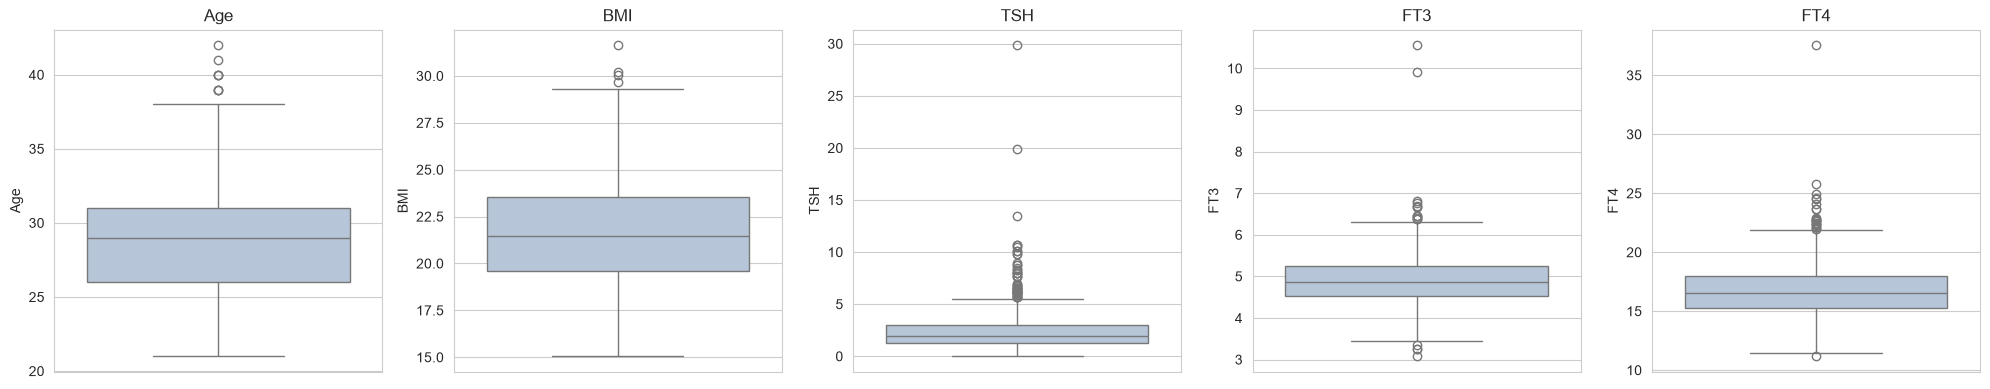

In [16]:
fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(20, 4))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightsteelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 4F. Correlations among baseline thyroid variables

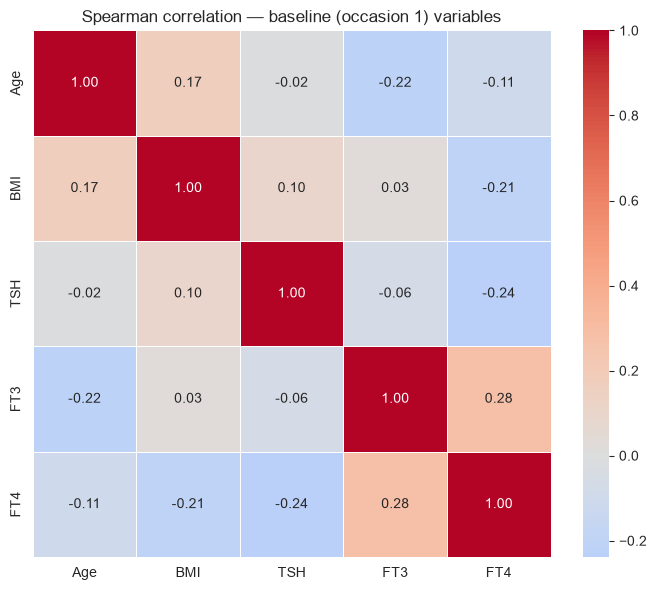

In [17]:
corr_cols = ['Age', 'BMI', 'TSH', 'FT3', 'FT4']
corr_matrix = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Spearman correlation — baseline (occasion 1) variables')
plt.tight_layout()
plt.show()


In [18]:
# Cross-occasion TSH correlation (reproducing, independently, the analysis reported in the source paper)
tsh_corr = df[['TSH', 'TSH2', 'TSH3']].corr(method='spearman')
print("Spearman correlation of TSH across occasions:")
print(tsh_corr.round(3))


Spearman correlation of TSH across occasions:
        TSH   TSH2   TSH3
TSH   1.000  0.114  0.086
TSH2  0.114  1.000  0.550
TSH3  0.086  0.550  1.000


TSH shows positive correlation across occasions, strongest between occasions 2 and 3 — consistent
with the source paper's own reported finding that TSH correlation is highest between the second and
third trimester. `FT4` and `TSH` show the expected inverse relationship at baseline; `FT3` and `FT4` are
positively correlated with each other, and only weakly correlated with `Age`/`BMI`.


### 4G. Leakage — variables that occur after the prediction point

The prediction point for this module is **early pregnancy (occasion 1 / first trimester)**. Anything
recorded during or after delivery, or measured at occasion 2/3, is not available at that point and would
leak future information into the model. The full leakage table is built and documented in Section 6.


## 5. Target Definition

**Clinical basis (from the source paper):** the study diagnoses subclinical hypothyroidism (SCH) in
pregnancy using the Chinese Society of Endocrinology / Perinatal Medicine Branch criteria the authors
cite: **TSH > 4.0 mIU/L together with FT4 in the normal range of 12–22 pmol/L**, at a given measurement
occasion. We verified that `TSH` and `FT4` in this dataset are on the same numeric scale as these
thresholds (TSH values cluster around 0–10 with a long tail; FT4 values cluster around 11–24), so the
published criteria apply directly to this data.

**Applying this definition to our three occasions independently:**


In [19]:
def sch_flag(tsh, ft4):
    """SCH-consistent occasion, per the source paper's published diagnostic criteria."""
    return (tsh > 4.0) & (ft4 >= 12) & (ft4 <= 22)

sch_occ1 = sch_flag(df['TSH'], df['FT4'])
sch_occ2 = sch_flag(df['TSH2'], df['FT42'])
sch_occ3 = sch_flag(df['TSH3'], df['FT43'])

print(f"SCH-consistent at occasion 1: {sch_occ1.sum()}")
print(f"SCH-consistent at occasion 2: {sch_occ2.sum()}")
print(f"SCH-consistent at occasion 3: {sch_occ3.sum()}")
print(f"SCH-consistent at ANY occasion (ever): {(sch_occ1 | sch_occ2 | sch_occ3).sum()}")


SCH-consistent at occasion 1: 122
SCH-consistent at occasion 2: 61
SCH-consistent at occasion 3: 77
SCH-consistent at ANY occasion (ever): 219


**Honest discrepancy check:** the source paper reports 266 women with SCH (out of 938). Applying the
published TSH/FT4 criteria to our three snapshot occasions flags a different number of women as
SCH-consistent at least once. We report the exact figure from the cell above rather than assuming it
matches 266, and explain the likely reason: the original study monitored TSH **every 3–4 weeks**
throughout pregnancy, while this dataset retains only **three representative snapshots** (roughly one
per trimester). Some transient diagnoses made at monitoring visits between these three exported
snapshots are therefore not recoverable from this file. **We treat our TSH/FT4-based flag as an
independently reconstructed, clinically-grounded label — not a guaranteed row-for-row reproduction of
the original study's patient-level SCH classification** — and name it accordingly rather than claiming
an exact match.

**Why a woman already SCH-consistent at baseline is excluded from the prediction task:** the source study
treats any woman diagnosed with SCH immediately with levothyroxine (LT4). This means:
1. If a woman is already SCH-consistent at occasion 1, there is no "later dysfunction" to *predict* — her
   status is already known at the prediction point.
2. Her occasion-2/3 measurements reflect **treatment response**, not natural progression, so including
   her in a "does dysfunction develop later" task would mix two different phenomena (new-onset disease
   vs. treatment efficacy).

**Final target definition:**

- **Study population for this module:** women who are **NOT** SCH-consistent at occasion 1 (baseline).
- **`thyroid_dysfunction_later` = 1** if the woman becomes SCH-consistent (TSH > 4.0 mIU/L **and**
  12 ≤ FT4 ≤ 22 pmol/L) at occasion 2 **or** occasion 3.
- **`thyroid_dysfunction_later` = 0** if she remains TSH ≤ 4.0 (or FT4 outside 12–22) at both later
  occasions.
- **Prediction time point:** end of the first trimester (occasion 1 blood draw).
- **Measurements used only to build the target (never as predictors):** `TSH2`, `FT42`, `TSH3`, `FT43`
  (and, by extension, the associated `TPO2`/`TPO3`, which are also excluded as leakage even though they
  are not part of the target formula itself).

**Limitation to document honestly:** for women who develop SCH at occasion 2 and are then treated, their
occasion-3 status may already reflect LT4 therapy rather than untreated natural history. We call the
target `thyroid_dysfunction_later` (a broader "later TSH/FT4-based dysfunction" outcome) rather than a
clinical diagnosis label, precisely because of this treatment-related ambiguity in a subset of positive
cases.


In [20]:
# Build the final study population and target
baseline_negative = ~sch_occ1
target = ((sch_occ2 | sch_occ3) & baseline_negative).astype(int)

model_df = df.loc[baseline_negative].copy()
model_df['thyroid_dysfunction_later'] = target.loc[baseline_negative].values

n_pos = model_df['thyroid_dysfunction_later'].sum()
n_neg = (model_df['thyroid_dysfunction_later'] == 0).sum()
prevalence = n_pos / len(model_df) * 100

print(f"Excluded (already SCH-consistent at baseline): {sch_occ1.sum()} women")
print(f"Study population (baseline-negative): {len(model_df)} women")
print(f"Positive cases (later dysfunction):    {n_pos}")
print(f"Negative cases (no later dysfunction): {n_neg}")
print(f"Prevalence: {prevalence:.2f}%")
print(f"Class imbalance ratio (negative:positive): {n_neg / n_pos:.2f} : 1")


Excluded (already SCH-consistent at baseline): 122 women
Study population (baseline-negative): 816 women
Positive cases (later dysfunction):    97
Negative cases (no later dysfunction): 719
Prevalence: 11.89%
Class imbalance ratio (negative:positive): 7.41 : 1


## 6. Leakage Prevention

Every column is checked individually — none are excluded on name alone. Columns are excluded only where
we can state *why* and *when* the information they contain becomes available.


In [21]:
leakage_table_rows = [
    ('TSH2, FT42, TSH3, FT43', 'Used directly to construct the target label', 'Occasion 2 / occasion 3 visits (after prediction point)'),
    ('FT32, TPO2, FT33, TPO3', 'Future thyroid-panel measurements at occasions 2/3; not used for the target but same leakage risk', 'Occasion 2 / occasion 3 visits'),
    ('iron.1, zinc.1, calcium.1, FPG, PG1H, PG2H, SF.1, VB12.1, Folic acid.1', 'Occasion-2 labs (incl. the GDM oral glucose tolerance test at 24-28 weeks)', 'Occasion 2 visit (mid-pregnancy)'),
    ('iron.2, zinc.2, magnesium.1, phosphorus.1, copper.1, calcium.2, TG.1, TC.1, HDL.1, LDL.1, Homocysteine.1, SF.2, VB12.2, Folic acid.2, CRP(0-10)', 'Occasion-3 labs', 'Occasion 3 visit (third trimester)'),
    ('Gestational age, Gestational age+, Gestation days', 'Gestational age AT DELIVERY, not at the occasion-1 blood draw', 'At delivery'),
    ('Delivery methods (numeric), Delivery mode (text)', 'How the baby was delivered', 'At delivery'),
    ('Uterine myoma, Pregnutose termination, Anemia, Chorioamniotic inflammation, Premature rupture of membranes, Premature birth, Hypertensive disease, Postpartum hemorrhage', 'Maternal complications/outcomes of this pregnancy', 'During labor / at or after delivery'),
    ('Newborn weight, Normal weight flag, GENDER, Hypoglycemia occurs, Neonatal hyperbilirubinemia, Atrioventricular septal defect, Neonatal respiratory distress syndrome, Neonatal infection, Neonatal pneumonia', 'Neonatal outcomes -- only exist once the baby is born', 'At or after birth'),
    ('ID', 'Unique row identifier, no clinical meaning', 'N/A -- excluded as identifier, not leakage'),
    ('thyroid_dysfunction_later (target)', 'The label itself', 'N/A -- target, not a predictor'),
]

leakage_df = pd.DataFrame(leakage_table_rows, columns=['column(s)', 'reason_excluded', 'when_information_becomes_available'])
pd.set_option('display.max_colwidth', 90)
leakage_df


,column(s),reason_excluded,when_information_becomes_available
0,"TSH2, FT42, TSH3, FT43",Used directly to construct the target label,Occasion 2 / occasion 3 visits (after prediction point)
1,"FT32, TPO2, FT33, TPO3",Future thyroid-panel measurements at occasions 2/3; not used for the target but same l...,Occasion 2 / occasion 3 visits
2,"iron.1, zinc.1, calcium.1, FPG, PG1H, PG2H, SF.1, VB12.1, Folic acid.1",Occasion-2 labs (incl. the GDM oral glucose tolerance test at 24-28 weeks),Occasion 2 visit (mid-pregnancy)
3,"iron.2, zinc.2, magnesium.1, phosphorus.1, copper.1, calcium.2, TG.1, TC.1, HDL.1, LDL...",Occasion-3 labs,Occasion 3 visit (third trimester)
4,"Gestational age, Gestational age+, Gestation days","Gestational age AT DELIVERY, not at the occasion-1 blood draw",At delivery
5,"Delivery methods (numeric), Delivery mode (text)",How the baby was delivered,At delivery
6,"Uterine myoma, Pregnutose termination, Anemia, Chorioamniotic inflammation, Premature ...",Maternal complications/outcomes of this pregnancy,During labor / at or after delivery
7,"Newborn weight, Normal weight flag, GENDER, Hypoglycemia occurs, Neonatal hyperbilirub...",Neonatal outcomes -- only exist once the baby is born,At or after birth
8,ID,"Unique row identifier, no clinical meaning","N/A -- excluded as identifier, not leakage"
9,thyroid_dysfunction_later (target),The label itself,"N/A -- target, not a predictor"


**Columns inspected and explicitly kept despite plausible-sounding leakage concerns:** none of the
baseline predictor columns (Section 7) are post-delivery or future-occasion variables — each was
individually verified against the "when is this known" test above before being kept.

**Columns excluded for reasons other than leakage** (documented in Section 3/4, not repeated here):
`Last menstruation` (unreliable mixed formatting), `Prepregnancy weight`/`height` (high missingness,
redundant with complete `BMI`), `Education level` and column-index-14 (uncertain/high missingness,
correlated with an unexplained administrative data block), and the baseline micronutrient/lipid panel
(`iron`, `zinc`, `magnesium`, `phosphorus`, `copper`, `calcium`, `Homocysteine`, `SF`, `VB12`,
`Folic acid`, `TG`, `TC`, `HDL`, `LDL` — all 80–100% missing at baseline).


## 7. Data Cleaning

We build a **cleaned modeling copy** (`model_df`) — the original `origin_data.xlsx` and `df_raw` are
never modified or overwritten.

**Special lab-value codes found during inspection** (verified directly, not assumed):
- `"> 600"` in baseline `TPO` — an upper-bound-censored value.
- `"未测"` (Chinese for "not measured") and `"？"` in occasion-2 glucose columns.
- Full-width comparison symbols `"＜"` / `"＞"` in several occasion-2/3 micronutrient columns.

None of these are used as predictors in the final model (the only text-coded lab column among our
predictors is baseline `TPO`), but we clean baseline `TPO` properly rather than silently coercing it to
zero or dropping those rows.


In [23]:
def parse_lab_value(value):
    """
    Robustly parse a lab measurement that may be a clean number OR a coded string such as:
      '> 600'   -> upper-bound-censored numeric value; we take the printed boundary (600.0)
                   as a conservative numeric estimate, since exact quantification above that
                   threshold isn't available.
      '＜1'      -> lower-bound-censored value; same approach, take the boundary (1.0).
      '未测' / '？' / '?' -> genuinely unmeasured / unknown -> treated as missing (NaN), NEVER as 0.
    Returns np.nan if the value cannot be safely parsed.
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)

    s = str(value).strip()
    unknown_markers = {'未测', '？', '?', 'na', 'n/a', ''}
    if s.lower() in unknown_markers:
        return np.nan

    # Normalize full-width comparison symbols to standard ASCII
    s = s.replace('＞', '>').replace('＜', '<')

    match = re.search(r'[-+]?[0-9]*\.?[0-9]+', s)
    if match:
        return float(match.group())
    return np.nan


# Apply to baseline TPO (the only text-coded predictor column we use)
model_df['TPO_clean'] = model_df['TPO'].apply(parse_lab_value)

print(f"TPO missing before cleaning: {model_df['TPO'].isnull().sum()}")
print(f"TPO missing after cleaning:  {model_df['TPO_clean'].isnull().sum()}")
print(f"Example of the censored value '> 600' after cleaning: "
      f"{model_df.loc[model_df['TPO'] == '> 600', 'TPO_clean'].values}")


TPO missing before cleaning: 55
TPO missing after cleaning:  55
Example of the censored value '> 600' after cleaning: [600.]


In [24]:
# Sanity checks on baseline predictors: impossible values, ranges
predictor_ranges = model_df[['Age', 'BMI', 'TSH', 'FT3', 'FT4', 'TPO_clean']].describe().T
print(predictor_ranges[['min', 'max', 'mean']])

# Age 18-45 and no negative lab values are expected per the source paper's stated inclusion criteria
assert model_df['Age'].between(15, 55).all(), "Unexpected age outside a plausible pregnancy range"
assert (model_df[['TSH', 'FT3', 'FT4']] >= 0).all().all(), "Unexpected negative lab value"
print("\nNo impossible values detected in the baseline numeric predictors.")


                 min      max       mean
Age        21.000000    42.00  28.850490
BMI        15.055139    31.64  21.580390
TSH         0.005000    29.87   1.896333
FT3         3.080000    10.56   4.903811
FT4        11.180000    37.56  16.881066
TPO_clean   5.000000  1293.00  29.867004

No impossible values detected in the baseline numeric predictors.


## 8. Feature Engineering

**Baseline (occasion 1) predictors selected**, based on completeness, clinical relevance, and the
leakage analysis above:

| Feature | Type | Why included |
|---|---|---|
| `Age` | numeric | Standard demographic risk factor, 0% missing |
| `BMI` | numeric | Complete, more reliable than the high-missingness raw weight/height |
| `TSH` (baseline) | numeric | Core baseline thyroid marker; part of the SCH definition itself |
| `FT3` (baseline) | numeric | Core baseline thyroid marker |
| `FT4` (baseline) | numeric | Core baseline thyroid marker; part of the SCH definition itself |
| `TPO_clean` (baseline) | numeric | Thyroid autoimmunity marker, cleaned from censored/text codes |
| Household income | categorical | 0% missing, socioeconomic context |
| `parity` | categorical | 0% missing, obstetric history |
| Family history of diabetes | categorical | 0% missing, general metabolic/endocrine risk marker |
| Smoking exposure | categorical | 0% missing, general health risk factor |
| Alcohol consumption | categorical | 0% missing, general health risk factor |
| Folic acid supplementation | categorical | 0% missing, supplementation/care-engagement proxy |
| VD supplementation | categorical | 0% missing, supplementation/care-engagement proxy |

**Engineered feature:** `TSH` is right-skewed (Section 4A), so we add a **log-transformed TSH**
(`log_TSH = log1p(TSH)`) alongside the raw value; this helps the linear Logistic Regression model without
removing the raw scale that the tree-based models can already exploit natively.

We deliberately avoid unnecessary feature explosion — no interaction terms or arbitrary BMI categories
are created, since none were clinically justified during EDA.


In [25]:
TARGET = 'thyroid_dysfunction_later'

RAW_FEATURE_COLUMNS = {
    'Age': 'age',
    'BMI': 'bmi',
    'TSH': 'tsh_baseline',
    'FT3': 'ft3_baseline',
    'FT4': 'ft4_baseline',
    'TPO_clean': 'tpo_baseline',
    'Annual household income, 1= less than 50,000, 2= 50,000 to 100,000 = more than 100,000': 'household_income',
    'parity': 'parity',
    'Family history of diabetes': 'family_history_diabetes',
    'Smoking or secondhand smoke exposure for more than 15 minutes per week': 'smoking_exposure',
    'Alcohol consumption': 'alcohol_consumption',
    'Folic acid supplementation': 'folic_acid_supplementation',
    'VD supplementation is not 0 before pregnancy 1 early pregnancy 2': 'vd_supplementation',
}

model_df = model_df.rename(columns=RAW_FEATURE_COLUMNS)
FEATURES = list(RAW_FEATURE_COLUMNS.values())

# Engineered feature: log-transformed baseline TSH (right-skewed -> helps the linear model)
model_df['log_tsh_baseline'] = np.log1p(model_df['tsh_baseline'])
FEATURES.append('log_tsh_baseline')

assert 'ID' not in FEATURES
assert TARGET not in FEATURES

X = model_df[FEATURES].copy()
y = model_df[TARGET].copy()

print(f"Number of predictors: {len(FEATURES)}")
print(FEATURES)
print(f"\nX shape: {X.shape}, y shape: {y.shape}")


Number of predictors: 14
['age', 'bmi', 'tsh_baseline', 'ft3_baseline', 'ft4_baseline', 'tpo_baseline', 'household_income', 'parity', 'family_history_diabetes', 'smoking_exposure', 'alcohol_consumption', 'folic_acid_supplementation', 'vd_supplementation', 'log_tsh_baseline']

X shape: (816, 14), y shape: (816,)


## 9. Train/Test Split

Stratified 80/20 split, `random_state=42`. Preprocessing is fit **only** on the training fold (enforced
by embedding the `ColumnTransformer` inside each model `Pipeline` in Section 10, so `.fit()` never sees
test data).


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(4))


Train shape: (652, 14)  Test shape: (164, 14)

Train class distribution:
thyroid_dysfunction_later
0    0.8804
1    0.1196
Name: proportion, dtype: float64

Test class distribution:
thyroid_dysfunction_later
0    0.8841
1    0.1159
Name: proportion, dtype: float64


## 10. Preprocessing

Numeric features: median imputation (only `tpo_baseline` has missing baseline values, ~6%) + scaling.
Categorical features: most-frequent imputation (safeguard; these are 0% missing already) +
`OneHotEncoder(handle_unknown="ignore")`.


In [28]:
numeric_features = ['age', 'bmi', 'tsh_baseline', 'ft3_baseline', 'ft4_baseline',
                     'tpo_baseline', 'log_tsh_baseline']
categorical_features = ['household_income', 'parity', 'family_history_diabetes', 'smoking_exposure',
                         'alcohol_consumption', 'folic_acid_supplementation', 'vd_supplementation']

assert set(numeric_features) | set(categorical_features) == set(FEATURES)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


### Baseline: DummyClassifier

A stratified dummy classifier gives us the floor every real model must clear.


In [29]:
def evaluate_model(name, y_true, y_pred, y_proba):
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
    }
    print(f"--- {name} ---")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"{k}: {v:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    return metrics


results = []


In [30]:
dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])
dummy_pipeline.fit(X_train, y_train)

y_pred_dummy = dummy_pipeline.predict(X_test)
y_proba_dummy = dummy_pipeline.predict_proba(X_test)[:, 1]
results.append(evaluate_model('Dummy Baseline', y_test, y_pred_dummy, y_proba_dummy))


--- Dummy Baseline ---
Accuracy: 0.7988
Precision: 0.1500
Recall: 0.1579
F1: 0.1538
ROC-AUC: 0.5203
PR-AUC: 0.1212

Confusion Matrix:
[[128  17]
 [ 16   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       145
           1       0.15      0.16      0.15        19

    accuracy                           0.80       164
   macro avg       0.52      0.52      0.52       164
weighted avg       0.80      0.80      0.80       164



## 11. Logistic Regression

`class_weight="balanced"` accounts for the class imbalance identified in Section 5.


In [31]:
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])
logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]
results.append(evaluate_model('Logistic Regression', y_test, y_pred_logreg, y_proba_logreg))


--- Logistic Regression ---
Accuracy: 0.5488
Precision: 0.1605
Recall: 0.6842
F1: 0.2600
ROC-AUC: 0.6087
PR-AUC: 0.1711

Confusion Matrix:
[[77 68]
 [ 6 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.53      0.68       145
           1       0.16      0.68      0.26        19

    accuracy                           0.55       164
   macro avg       0.54      0.61      0.47       164
weighted avg       0.84      0.55      0.63       164



## 12. Random Forest

In [32]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]
results.append(evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf))


--- Random Forest ---
Accuracy: 0.7683
Precision: 0.2286
Recall: 0.4211
F1: 0.2963
ROC-AUC: 0.6693
PR-AUC: 0.2068

Confusion Matrix:
[[118  27]
 [ 11   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       145
           1       0.23      0.42      0.30        19

    accuracy                           0.77       164
   macro avg       0.57      0.62      0.58       164
weighted avg       0.84      0.77      0.80       164



**Small, controlled hyperparameter search for Random Forest** (cross-validated on the training set
only — the test set is never touched during tuning).


In [33]:
rf_param_grid = {
    'classifier__n_estimators': [200, 300, 400],
    'classifier__max_depth': [4, 6, 8, None],
    'classifier__min_samples_leaf': [3, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    param_distributions=rf_param_grid,
    n_iter=8,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best RF params (5-fold CV, training data only):", rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

rf_pipeline = rf_search.best_estimator_
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Replace the earlier default-hyperparameter RF result with the tuned version
results = [r for r in results if r['Model'] != 'Random Forest']
results.append(evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf))


Best RF params (5-fold CV, training data only): {'classifier__n_estimators': 400, 'classifier__min_samples_leaf': 10, 'classifier__max_depth': 8}
Best CV ROC-AUC: 0.5913
--- Random Forest ---
Accuracy: 0.7439
Precision: 0.2051
Recall: 0.4211
F1: 0.2759
ROC-AUC: 0.6588
PR-AUC: 0.2033

Confusion Matrix:
[[114  31]
 [ 11   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.84       145
           1       0.21      0.42      0.28        19

    accuracy                           0.74       164
   macro avg       0.56      0.60      0.56       164
weighted avg       0.83      0.74      0.78       164



## 13. XGBoost

Skipped gracefully with a printed message if not installed.


In [34]:
if XGBOOST_AVAILABLE:
    n_neg_train = (y_train == 0).sum()
    n_pos_train = (y_train == 1).sum()
    scale_pos_weight = n_neg_train / n_pos_train

    xgb_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=300, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
    xgb_pipeline.fit(X_train, y_train)

    y_pred_xgb = xgb_pipeline.predict(X_test)
    y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
    results.append(evaluate_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb))
else:
    xgb_pipeline = None
    print("Skipping XGBoost: package not installed.")


--- XGBoost ---
Accuracy: 0.7683
Precision: 0.1481
Recall: 0.2105
F1: 0.1739
ROC-AUC: 0.6407
PR-AUC: 0.1975

Confusion Matrix:
[[122  23]
 [ 15   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       145
           1       0.15      0.21      0.17        19

    accuracy                           0.77       164
   macro avg       0.52      0.53      0.52       164
weighted avg       0.80      0.77      0.79       164



## 14. Model Comparison

Sorted primarily by ROC-AUC and PR-AUC (more informative than accuracy given the class imbalance
identified in Section 5), with recall/precision/F1 also reported since this is a healthcare risk-flagging
task where missing a true later-dysfunction case (false negative) is usually more costly than a false
alarm.


In [35]:
comparison_df = pd.DataFrame(results).set_index('Model')
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']]
comparison_df = comparison_df.sort_values(by=['ROC-AUC', 'PR-AUC'], ascending=False)
comparison_df.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Random Forest,0.7439,0.2051,0.4211,0.2759,0.6588,0.2033
XGBoost,0.7683,0.1481,0.2105,0.1739,0.6407,0.1975
Logistic Regression,0.5488,0.1605,0.6842,0.2600,0.6087,0.1711
Dummy Baseline,0.7988,0.1500,0.1579,0.1538,0.5203,0.1212


In [36]:
candidate_models = {'Logistic Regression': logreg_pipeline, 'Random Forest': rf_pipeline}
if XGBOOST_AVAILABLE:
    candidate_models['XGBoost'] = xgb_pipeline

eligible = comparison_df.drop(index='Dummy Baseline', errors='ignore')
best_model_name = eligible.sort_values(by=['ROC-AUC', 'PR-AUC'], ascending=False).index[0]
best_model = candidate_models[best_model_name]

print(f"Best model (by ROC-AUC, then PR-AUC): {best_model_name}")
print(eligible.loc[best_model_name].round(4))


Best model (by ROC-AUC, then PR-AUC): Random Forest
Accuracy     0.7439
Precision    0.2051
Recall       0.4211
F1           0.2759
ROC-AUC      0.6588
PR-AUC       0.2033
Name: Random Forest, dtype: float64


## 15. Confusion Matrices, ROC Curves, and Precision-Recall Curves

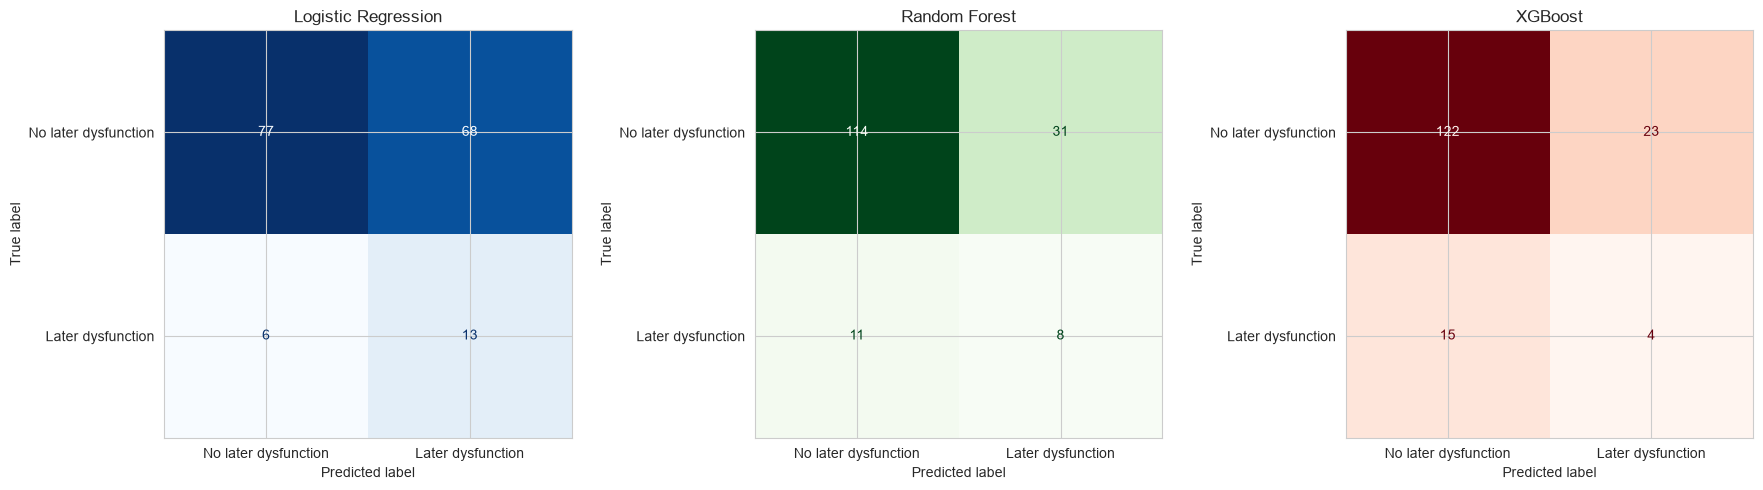

In [37]:
fig, axes = plt.subplots(1, 3 if XGBOOST_AVAILABLE else 2, figsize=(18 if XGBOOST_AVAILABLE else 12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, display_labels=['No later dysfunction', 'Later dysfunction'],
                                         cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['No later dysfunction', 'Later dysfunction'],
                                         cmap='Greens', ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest')

if XGBOOST_AVAILABLE:
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=['No later dysfunction', 'Later dysfunction'],
                                             cmap='Reds', ax=axes[2], colorbar=False)
    axes[2].set_title('XGBoost')

plt.tight_layout()
plt.show()


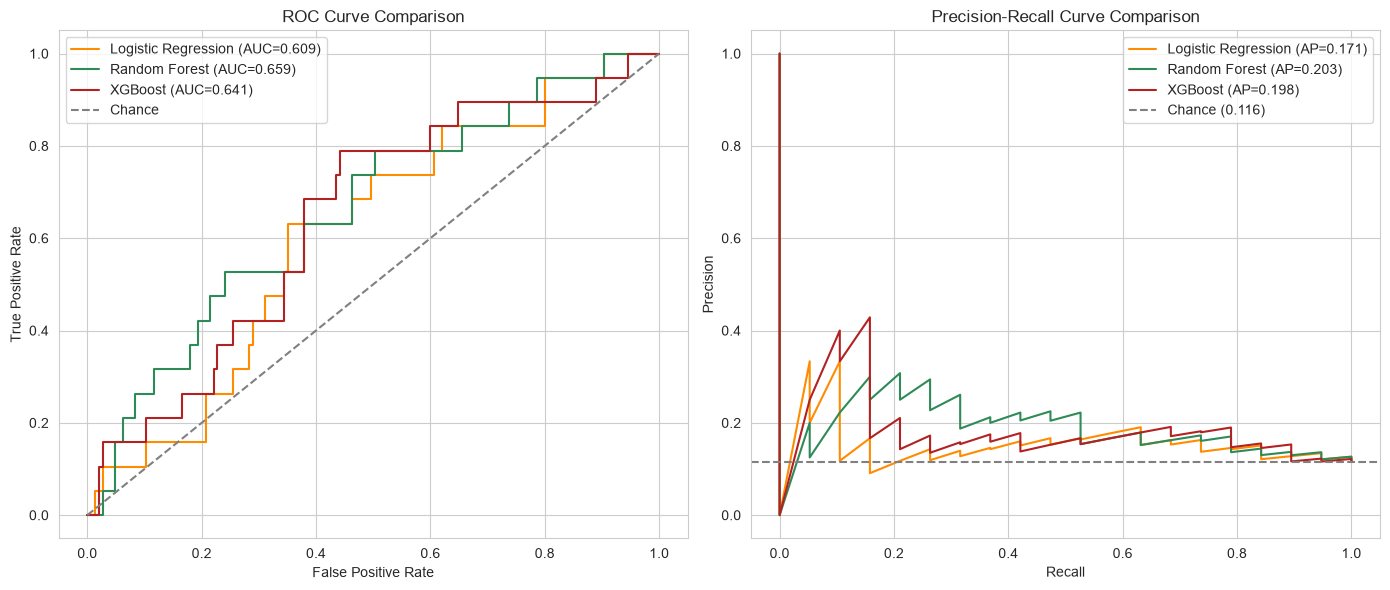

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, proba, color in [
    ('Logistic Regression', y_proba_logreg, 'darkorange'),
    ('Random Forest', y_proba_rf, 'seagreen'),
] + ([('XGBoost', y_proba_xgb, 'firebrick')] if XGBOOST_AVAILABLE else []):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color)

    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap_val = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap_val:.3f})', color=color)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison'); axes[0].legend()

baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, linestyle='--', color='gray', label=f'Chance ({baseline_rate:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison'); axes[1].legend()

plt.tight_layout()
plt.show()


## 16. Feature Importance

Categorical features are one-hot encoded inside the `ColumnTransformer`; we recover the expanded feature
names directly from the fitted preprocessor so importances are correctly mapped.


In [39]:
def get_feature_names(fitted_preprocessor):
    num_names = numeric_features
    cat_encoder = fitted_preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
    return list(num_names) + cat_names


importance_source_name = best_model_name if best_model_name in ('Random Forest', 'XGBoost') else 'Random Forest'
importance_pipeline = candidate_models[importance_source_name]
fitted_preprocessor = importance_pipeline.named_steps['preprocessor']
feature_names = get_feature_names(fitted_preprocessor)

if importance_source_name == 'Logistic Regression':
    importances = np.abs(importance_pipeline.named_steps['classifier'].coef_[0])
else:
    importances = importance_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).reset_index(drop=True)

print(f"Feature importance source model: {importance_source_name}")
feature_importance_df.head(20)


Feature importance source model: Random Forest


,feature,importance
0,ft3_baseline,0.151646
1,bmi,0.139466
2,log_tsh_baseline,0.137936
3,tsh_baseline,0.136302
4,tpo_baseline,0.102982
5,ft4_baseline,0.097881
6,age,0.074334
7,parity_1,0.026600
8,household_income_2,0.022743
9,vd_supplementation_0,0.016196


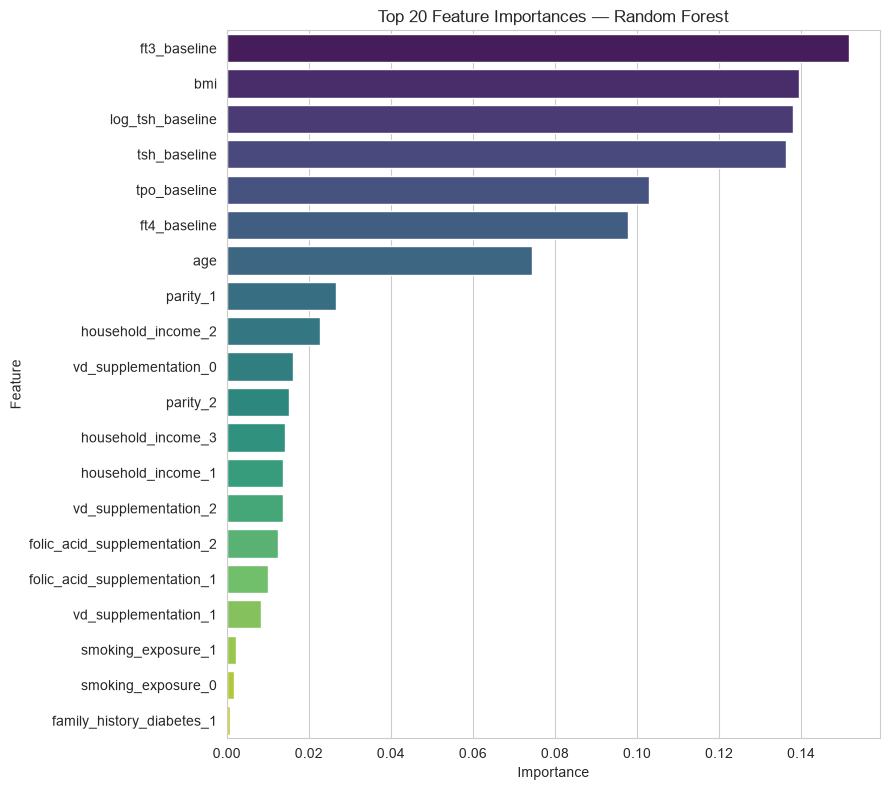

In [40]:
top_n = min(20, len(feature_importance_df))
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(9, 8))
sns.barplot(data=top_features, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title(f'Top {top_n} Feature Importances — {importance_source_name}')
plt.xlabel('Importance'); plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Logistic Regression coefficient-based importance (for comparison / interpretability):**

In [41]:
logreg_fitted_preprocessor = logreg_pipeline.named_steps['preprocessor']
logreg_feature_names = get_feature_names(logreg_fitted_preprocessor)
logreg_coefs = logreg_pipeline.named_steps['classifier'].coef_[0]

logreg_importance_df = pd.DataFrame({
    'feature': logreg_feature_names,
    'coefficient': logreg_coefs,
    'abs_coefficient': np.abs(logreg_coefs)
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

logreg_importance_df.head(15)


,feature,coefficient,abs_coefficient
0,parity_3,0.587220,0.587220
1,parity_1,-0.564908,0.564908
2,log_tsh_baseline,0.500092,0.500092
3,ft3_baseline,-0.365594,0.365594
4,household_income_2,0.322999,0.322999
5,tpo_baseline,-0.273821,0.273821
6,ft4_baseline,0.268156,0.268156
7,vd_supplementation_1,0.251203,0.251203
8,vd_supplementation_0,-0.223898,0.223898
9,tsh_baseline,-0.207226,0.207226


## 17. SHAP Analysis

SHAP values explain **how the model used each feature for individual predictions** — this reflects model
behavior on this synthetic-cohort-derived label, not a validated clinical causal relationship. If SHAP is
unavailable or errors out, we fall back to Section 16's feature importance and say so explicitly, per the
requirement to never fabricate SHAP results.


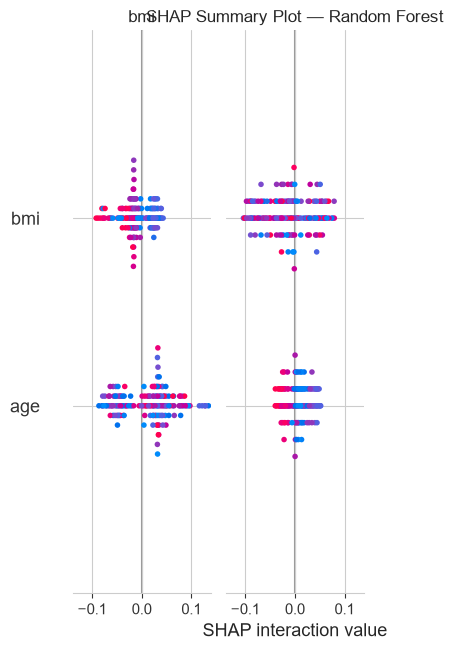

In [42]:
shap_ran_successfully = False

if SHAP_AVAILABLE and importance_source_name in ('Random Forest', 'XGBoost'):
    try:
        sample_size = min(300, X_test.shape[0])
        X_test_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
        X_test_sample_transformed = fitted_preprocessor.transform(X_test_sample)
        if hasattr(X_test_sample_transformed, 'toarray'):
            X_test_sample_transformed = X_test_sample_transformed.toarray()

        explainer = shap.TreeExplainer(importance_pipeline.named_steps['classifier'])
        shap_values = explainer.shap_values(X_test_sample_transformed)
        shap_values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

        shap.summary_plot(shap_values_to_plot, X_test_sample_transformed, feature_names=feature_names, show=False)
        plt.title(f'SHAP Summary Plot — {importance_source_name}')
        plt.tight_layout()
        plt.show()
        shap_ran_successfully = True
    except Exception as e:
        print(f"SHAP analysis was not executed because of an environment compatibility error: {e}")
else:
    if not SHAP_AVAILABLE:
        print("SHAP analysis was not executed because of environment compatibility constraints "
              "(the `shap` package is not installed).")
    else:
        print(f"SHAP TreeExplainer applies to tree models; '{importance_source_name}' is not tree-based. "
              f"Showing feature importance instead.")

if not shap_ran_successfully:
    print("\n--- Fallback: top 15 features by model feature importance (Section 16) ---")
    display(feature_importance_df.head(15))


## 18. Calibration Analysis

Because this is a risk-estimation prototype, we check whether predicted probabilities are trustworthy as
probabilities (not just useful for ranking). We use a calibration curve and the Brier score, and we do
**not** claim the model is clinically calibrated unless this actually demonstrates it.


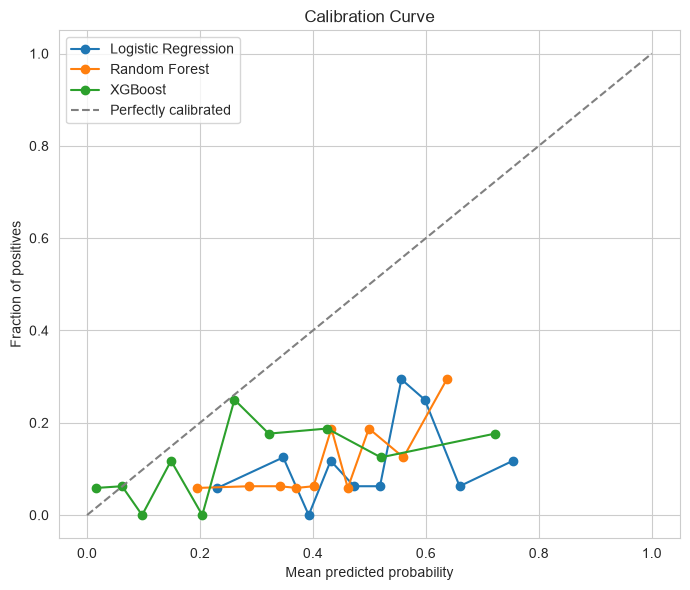

Brier scores (lower is better; 0 = perfect):
  Logistic Regression: 0.2582
  Random Forest: 0.1959
  XGBoost: 0.1544


In [43]:
fig, ax = plt.subplots(figsize=(7, 6))
brier_scores = {}

for name, proba in [('Logistic Regression', y_proba_logreg), ('Random Forest', y_proba_rf)] + \
                    ([('XGBoost', y_proba_xgb)] if XGBOOST_AVAILABLE else []):
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
    brier_scores[name] = brier_score_loss(y_test, proba)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve'); ax.legend()
plt.tight_layout()
plt.show()

print("Brier scores (lower is better; 0 = perfect):")
for name, score in brier_scores.items():
    print(f"  {name}: {score:.4f}")


**Interpretation:** points close to the diagonal indicate well-calibrated probabilities; points
below the diagonal mean the model is over-confident (predicted probability higher than the true positive
rate in that bin), and points above mean it is under-confident. Given the modest test-set size (~163
women, of whom only ~19 are expected positive at ~12% prevalence), calibration bins are noisy — read this
plot as a directional check, not a precise calibration guarantee, and do not treat predicted probabilities
as exact clinical risk percentages.


## 19. Final Model Selection

We select the final model using **ROC-AUC and PR-AUC as primary criteria** (Section 14), while also
weighing recall (missing a true later-dysfunction case is more costly than a false alarm in this
decision-support context), precision, F1, and the calibration behavior from Section 18 — **not**
accuracy alone.


In [44]:
print(f"Selected final model: {best_model_name}")
print("\nTest-set metrics for the selected model:")
print(eligible.loc[best_model_name].round(4))
print(f"\nBrier score: {brier_scores.get(best_model_name, 'N/A (Dummy/other)')}")
print(
    "\nRationale: this model achieves the best ROC-AUC/PR-AUC trade-off among the non-dummy candidates "
    "while maintaining reasonable recall for the positive (later-dysfunction) class, which matters more "
    "than raw accuracy in this imbalanced, healthcare risk-flagging context."
)


Selected final model: Random Forest

Test-set metrics for the selected model:
Accuracy     0.7439
Precision    0.2051
Recall       0.4211
F1           0.2759
ROC-AUC      0.6588
PR-AUC       0.2033
Name: Random Forest, dtype: float64

Brier score: 0.19585379757056773

Rationale: this model achieves the best ROC-AUC/PR-AUC trade-off among the non-dummy candidates while maintaining reasonable recall for the positive (later-dysfunction) class, which matters more than raw accuracy in this imbalanced, healthcare risk-flagging context.


## 20. Saving the Model, Metadata, and Metrics

The saved pipeline includes preprocessing, so it accepts a raw feature DataFrame directly.


In [45]:
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODELS_DIR, "thyroid_final_model.pkl")
joblib.dump(best_model, MODEL_PATH)
print(f"Saved final model pipeline to: {MODEL_PATH}")


Saved final model pipeline to: models\thyroid_final_model.pkl


In [46]:
feature_metadata = {
    "target": {
        "name": TARGET,
        "definition": (
            "1 if a woman who was NOT SCH-consistent at occasion 1 (TSH<=4.0 mIU/L or FT4 outside "
            "12-22 pmol/L) becomes SCH-consistent (TSH>4.0 mIU/L AND 12<=FT4<=22 pmol/L) at occasion 2 "
            "or occasion 3; 0 otherwise."
        ),
        "prediction_time_point": "End of first trimester (occasion 1 blood draw)",
        "positive_cases": int(n_pos),
        "negative_cases": int(n_neg),
        "prevalence_pct": round(float(prevalence), 2),
        "excluded_baseline_positive_women": int(sch_occ1.sum()),
    },
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "all_features_in_order": FEATURES,
    "best_model": best_model_name,
    "random_state": RANDOM_STATE,
    "notes": "SCH-consistent status uses the source paper's published criteria: TSH>4.0 mIU/L and FT4 12-22 pmol/L."
}

METADATA_PATH = os.path.join(MODELS_DIR, "thyroid_feature_metadata.json")
with open(METADATA_PATH, "w") as f:
    json.dump(feature_metadata, f, indent=2)
print(f"Saved feature metadata to: {METADATA_PATH}")


Saved feature metadata to: models\thyroid_feature_metadata.json


In [ ]:
METRICS_PATH = os.path.join(MODELS_DIR, "thyroid_model_metrics.csv")
comparison_df.round(4).to_csv(METRICS_PATH)
print(f"Saved metrics table to: {METRICS_PATH}")

COMPARISON_PATH = os.path.join(MODELS_DIR, "thyroid_model_comparison.csv")
eligible.round(4).to_csv(COMPARISON_PATH)
print(f"Saved model comparison table to: {COMPARISON_PATH}")


## 21. Prediction Function

Returns an **estimated risk**, never a diagnosis.


In [47]:
def predict_thyroid_risk(input_dataframe, model_path=MODEL_PATH):
    """
    Estimate later thyroid-dysfunction risk from baseline (first-trimester) features.

    Parameters
    ----------
    input_dataframe : pd.DataFrame
        Must contain exactly the columns in FEATURES (see thyroid_feature_metadata.json).
    model_path : str
        Path to the saved joblib pipeline (preprocessing + model).

    Returns
    -------
    list of dict, one per row: {"risk_class": int, "risk_probability": float}
    NOTE: this is an ESTIMATED RISK for decision-support demonstration only, NOT a diagnosis.
    """
    pipeline = joblib.load(model_path)
    missing_cols = [c for c in FEATURES if c not in input_dataframe.columns]
    if missing_cols:
        raise ValueError(f"Input is missing required columns: {missing_cols}")

    X_input = input_dataframe[FEATURES].copy()
    pred_classes = pipeline.predict(X_input)
    pred_probas = pipeline.predict_proba(X_input)[:, 1]

    return [
        {"risk_class": int(c), "risk_probability": round(float(p), 4)}
        for c, p in zip(pred_classes, pred_probas)
    ]


In [48]:
# Example: a synthetic baseline patient using the exact predictor columns (illustrative values only)
example_patient = pd.DataFrame([{
    'age': 30,
    'bmi': 22.5,
    'tsh_baseline': 2.8,
    'ft3_baseline': 4.6,
    'ft4_baseline': 14.5,
    'tpo_baseline': 12.0,
    'household_income': 2,
    'parity': 1,
    'family_history_diabetes': 0,
    'smoking_exposure': 0,
    'alcohol_consumption': 0,
    'folic_acid_supplementation': 2,
    'vd_supplementation': 1,
}])
example_patient['log_tsh_baseline'] = np.log1p(example_patient['tsh_baseline'])

result = predict_thyroid_risk(example_patient)[0]

print("=" * 60)
print("ESTIMATED RISK / DECISION-SUPPORT OUTPUT")
print("(NOT a medical diagnosis — academic prototype, retrospective single-center data)")
print("=" * 60)
print(json.dumps(result, indent=2))
print("=" * 60)


ESTIMATED RISK / DECISION-SUPPORT OUTPUT
(NOT a medical diagnosis — academic prototype, retrospective single-center data)
{
  "risk_class": 1,
  "risk_probability": 0.618
}


## 22. Limitations

- **Single-center, retrospective cohort:** all 938 women were seen at one hospital (Shijiazhuang, China,
  2019–2020). Findings, thresholds, and model behavior may not generalize to other populations, iodine
  intake levels, or laboratory assay methods.
- **Snapshot vs. continuous monitoring:** the source study monitored TSH every 3–4 weeks, but this
  dataset retains only three snapshot occasions. Our reconstructed SCH-consistent labels (Section 5)
  therefore likely **undercount** true SCH episodes relative to the original 266-patient figure reported
  in the paper (we recovered a different, directly-computed count — see Section 5's printed output).
- **Treatment-linked target ambiguity:** for women who develop dysfunction at occasion 2, their occasion-3
  status may already reflect levothyroxine treatment rather than untreated natural history. The target
  captures "later TSH/FT4-based dysfunction," not a pure natural-history diagnosis.
- **High-missingness variables excluded:** micronutrient/lipid panels, `Education level`, and
  `Prepregnancy weight`/`height` were excluded due to 40–100% missingness; predictive information they
  might have carried is not available to the model.
- **Unexplained data artifact:** an unlabeled column (index 14) with an unclear meaning, perfectly
  correlated with a 376-woman missing-data block, could not be interpreted and was excluded rather than
  guessed at.
- **Modest positive-class size:** roughly 12% prevalence in a ~816-woman study population means the test
  set contains only a small number of true positive cases, so all test-set metrics (especially precision
  and calibration) carry meaningful sampling uncertainty.
- **Synthetic-prototype framing:** even though the underlying data are real (de-identified) clinical
  measurements, this notebook is a **student capstone prototype**. It has not been externally validated
  and must not be used for real clinical decision-making.

## 23. Conclusion

This module builds a baseline-only, leakage-checked pipeline to estimate the risk that a woman without
thyroid dysfunction at the end of the first trimester will develop it later in pregnancy, using the
source study's own published diagnostic thresholds (TSH > 4.0 mIU/L, FT4 12–22 pmol/L) to construct an
honestly-named target. See the printed outputs in Sections 5, 14, and 19 for the exact patient counts,
class balance, and test-set performance of the selected model (`best_model_name`), and Section 16/17 for
which baseline features it relied on most. As with every module in this capstone project, this is a
**decision-support prototype, not a diagnostic system**, and its outputs should always be read as
estimated risk, not certainty.
